In [8]:
from pathlib import Path
import csv
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import matplotlib.colors as colors

from utils import graphics
from buryn_utils import location_utils, weight_utils

graphics.set_matplotlib_settings()

In [9]:
BURYNOUTPUTS_DIR = '../data/buryn_data/buryn_outputs_21'
GROUP_E_LOCATIONS_FILEPATH = Path(BURYNOUTPUTS_DIR+'/locations/group_e_locations.txt')
STEP=1000000
WEIGHTS_E_TO_E_FILEPATH = Path(BURYNOUTPUTS_DIR+'/weights/weights_step0.txt')
# WEIGHTS_E_TO_E_FILEPATH = Path(BURYNOUTPUTS_DIR+f'/recordings/weights_e_to_e_step{STEP}.txt')

for filepath in (
    GROUP_E_LOCATIONS_FILEPATH,
    WEIGHTS_E_TO_E_FILEPATH,
):
    if not filepath.exists():
        raise FileNotFoundError(f'Could not find {filepath.resolve()}')


In [10]:
group_e_neuron_ids, group_e_neuron_locations = location_utils.load_neuron_locations(
    GROUP_E_LOCATIONS_FILEPATH
)
group_e_location_by_id = {
    int(neuron_id): location
    for neuron_id, location in zip(group_e_neuron_ids, group_e_neuron_locations)
}
weights_e_to_e = weight_utils.load_weights(WEIGHTS_E_TO_E_FILEPATH)

In [11]:
def infer_shape(weights):
    pre_ids = list(set([entry[0] for entry in weights]))
    post_ids = list(set([entry[1] for entry in weights]))
    return len(pre_ids), len(post_ids), pre_ids, post_ids

def build_weight_matrix(weights, shape, all_neuron_ids):
    matrix = np.zeros(shape, dtype=float)
    for pre_id, post_id, weight in weights:
        pre_id_matrix_location = all_neuron_ids.index(pre_id)
        post_id_matrix_location = all_neuron_ids.index(post_id)
        matrix[pre_id_matrix_location, post_id_matrix_location] = weight
    return matrix

num_e_pre, num_e_post, all_neuron_ids, _ = infer_shape(weights_e_to_e)
shape_e_to_e = (num_e_pre, num_e_post)
weights_e_to_e_matrix = build_weight_matrix(weights_e_to_e, shape_e_to_e, all_neuron_ids)

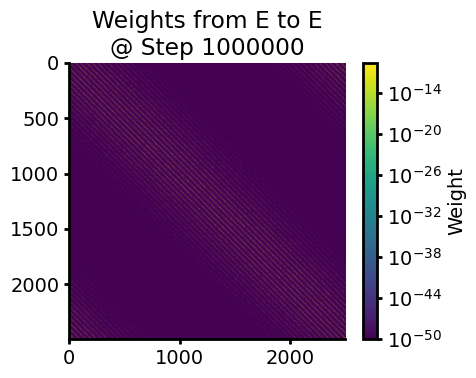

In [12]:
plt.imshow(
    weights_e_to_e_matrix + 1e-50,  # Add a small constant to avoid log(0)
    cmap='viridis',
    norm=colors.LogNorm()
)
# plt.xticks(range(len(all_neuron_ids)), all_neuron_ids, rotation=90)
# plt.yticks(range(len(all_neuron_ids)), all_neuron_ids)
plt.title(f"Weights from E to E\n@ Step {STEP}")
plt.colorbar(label='Weight')
plt.savefig(f"{BURYNOUTPUTS_DIR}/plots/entire_weight_matrix_e_to_e_step{STEP}.png", bbox_inches='tight')
plt.show()

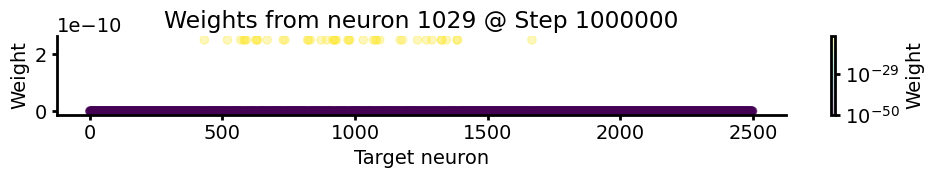

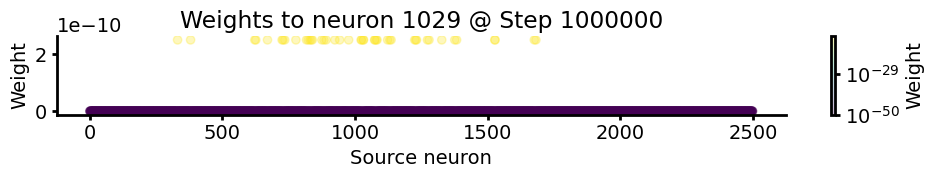

In [13]:
specific_neuron_id = 1029

row_idx = specific_neuron_id
row_weights = weights_e_to_e_matrix[row_idx, :] + 1e-50
plt.figure(figsize=(10, 2))
sc = plt.scatter(
    range(len(row_weights)),
    row_weights,
    c=row_weights,
    cmap='viridis',
    norm=colors.LogNorm(),
    alpha=0.3
)
# plt.yscale('log')
plt.title(f"Weights from neuron {row_idx} @ Step {STEP}")
plt.xlabel("Target neuron")
plt.ylabel("Weight")
plt.colorbar(sc, label="Weight")
plt.savefig(f"{BURYNOUTPUTS_DIR}/plots/weights_from_neuron_{specific_neuron_id}_step{STEP}.png", bbox_inches='tight')
plt.show()


col_idx = row_idx
col_weights = weights_e_to_e_matrix[:, col_idx] + 1e-50
plt.figure(figsize=(10, 2))
sc = plt.scatter(
    range(len(col_weights)),
    col_weights,
    c=col_weights,
    cmap='viridis',
    norm=colors.LogNorm(),
    alpha=0.3
)
# plt.yscale('log')
plt.title(f"Weights to neuron {col_idx} @ Step {STEP}")
plt.xlabel("Source neuron")
plt.ylabel("Weight")
plt.colorbar(sc, label="Weight")
plt.savefig(f"{BURYNOUTPUTS_DIR}/plots/weights_to_neuron_{specific_neuron_id}_step{STEP}.png", bbox_inches='tight')
plt.show()

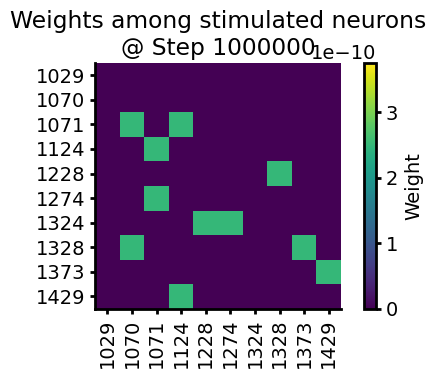

In [16]:
indices = [1029, 1070, 1071, 1124, 1228, 1274, 1324, 1328, 1373, 1429]
submatrix = weights_e_to_e_matrix[np.ix_(indices, indices)]
plt.imshow(
    submatrix + 1e-50,
    cmap='viridis',
    vmax = 3.75e-10,
    # norm=colors.LogNorm()
)
plt.xticks(range(len(indices)), indices, rotation=90)
plt.yticks(range(len(indices)), indices)
plt.title(f"Weights among stimulated neurons\n@ Step {STEP}")
plt.colorbar(label='Weight')
plt.savefig(f"{BURYNOUTPUTS_DIR}/plots/weights_among_stimulated_neurons_step{STEP}.png", bbox_inches='tight')
plt.show()